# Validacion del CBR: Leave-One-Out 

## 1. Imports y configuracion

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

from cbr_loio_eval import (
    BLOCK_WEIGHTS,
    DEFAULT_DATASET,
    DEFAULT_IMAGE_SIMILARITY,
    MULTIVALUE_FIELDS,
    PROBLEM_FEATURES,
    SOLUTION_FIELDS,
    build_dataset,
    jaccard_score,
    leave_one_image_out_clean,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)

DATASET = DEFAULT_DATASET
IMAGE_SIMILARITY_PATH = DEFAULT_IMAGE_SIMILARITY
K_REFERENCE = 11
K_VALUES = [1, 3, 5, 7, 9, 11, 15]

DATASET, IMAGE_SIMILARITY_PATH, K_REFERENCE

(PosixPath('../base_de_casos/cbr_case_base_outputs/case_base_double_full.csv'),
 PosixPath('../base_de_casos/cbr_similarity_outputs/image_ssim_by_id.csv'),
 11)

## 2. Carga de la base de casos

La base de casos contiene una fila por interaccion usuario-imagen.

In [25]:
df = build_dataset(DATASET)

print(f'Casos: {len(df)}')
print(f'Imagenes distintas: {df["image_id"].nunique()}')
print(f'Usuarios distintos: {df["user_id"].nunique()}')

df[['case_id', 'user_id', 'image_id', 'model_predicted_class', 'selected_option']].head(5)

Casos: 297
Imagenes distintas: 11
Usuarios distintos: 27


,case_id,user_id,image_id,model_predicted_class,selected_option
0,C0001,U001,1,NaN,Opción B
1,C0002,U001,2,NaN,Opción A
2,C0003,U001,3,NaN,Opción E
3,C0004,U001,4,NaN,Opción C
4,C0005,U001,5,NaN,Opción F (Ninguna)


## 3. Separacion problema-solucion

La validacion limpia se basa en una separacion estricta:

- **Atributos de problema**: informacion conocida antes de recomendar una explicacion.
- **Campos de solucion**: preferencias o decisiones que el CBR debe recuperar o predecir.

Los campos de solucion no se usan para calcular la similitud.

In [26]:
problem_solution_overlap = set(PROBLEM_FEATURES) & set(SOLUTION_FIELDS)
assert not problem_solution_overlap, problem_solution_overlap

print('Atributos de problema:')
display(pd.DataFrame({'problem_feature': PROBLEM_FEATURES}))

print('Campos de solucion evaluados:')
display(pd.DataFrame({'solution_field': SOLUTION_FIELDS}))

print('Campos multivalor evaluados tambien con Jaccard:')
display(pd.DataFrame({'multivalue_field': MULTIVALUE_FIELDS}))

Atributos de problema:


,problem_feature
0,problem_text
1,ai_knowledge_level
2,domain_knowledge_level
3,age_range
4,education_level
5,occupation_raw
6,image_id
7,domain
8,model_predicted_class


Campos de solucion evaluados:


,solution_field
0,selected_option
1,preferred_response_length
2,preferred_technical_level
3,preferred_format
4,perceived_error_impact
5,preferred_explanation_types_raw
6,main_goals_raw


Campos multivalor evaluados tambien con Jaccard:


,multivalue_field
0,preferred_explanation_types_raw
1,main_goals_raw


## 4. Similitud CBR por bloques

El CBR combina tres bloques de similitud:

- `text`: similitud textual TF-IDF sobre `problem_text`.
- `profile`: similitud del perfil mediante variables numericas y categoricas.
- `image`: similitud visual precalculada por imagen, si esta disponible.

La combinacion se hace con los pesos definidos en `BLOCK_WEIGHTS`.

In [27]:
pd.DataFrame([
    {'block': block, 'weight': weight}
    for block, weight in BLOCK_WEIGHTS.items()
])

,block,weight
0,text,0.4
1,profile,0.4
2,image,0.2


## 5. Ejecucion Leave-One-Image-Out para `k=11`

En cada fold se deja fuera una imagen completa. El sistema recupera vecinos usando solo casos de las demas imagenes y predice los campos de solucion mediante voto ponderado por similitud.

Se usa `k=11` como configuracion de referencia porque, en el analisis de sensibilidad, mejora la accuracy media respecto a `k=7` manteniendo un F1-macro medio muy similar.

In [28]:
folds_df, preds_df, neighbors_df, metrics_df = leave_one_image_out_clean(
    df,
    k=K_REFERENCE,
    exclude_same_user=True,
    image_similarity_path=IMAGE_SIMILARITY_PATH,
)

print(f'Folds: {len(folds_df)}')
print(f'Predicciones: {len(preds_df)}')
print(f'Vecinos guardados: {len(neighbors_df)}')

folds_df.head()

/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['model_predicted_class']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['model_predicted_class']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['model_predicted_class']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packa

Folds: 11
Predicciones: 297
Vecinos guardados: 3267


,image_id,n_val_samples,accuracy_selected_option,baseline_accuracy_selected_option,f1_macro_selected_option,accuracy_preferred_response_length,baseline_accuracy_preferred_response_length,f1_macro_preferred_response_length,accuracy_preferred_technical_level,baseline_accuracy_preferred_technical_level,f1_macro_preferred_technical_level,accuracy_preferred_format,baseline_accuracy_preferred_format,f1_macro_preferred_format,accuracy_perceived_error_impact,baseline_accuracy_perceived_error_impact,f1_macro_perceived_error_impact,accuracy_preferred_explanation_types_raw,baseline_accuracy_preferred_explanation_types_raw,f1_macro_preferred_explanation_types_raw,jaccard_preferred_explanation_types_raw,baseline_jaccard_preferred_explanation_types_raw,accuracy_main_goals_raw,baseline_accuracy_main_goals_raw,f1_macro_main_goals_raw,jaccard_main_goals_raw,baseline_jaccard_main_goals_raw
0,1,27,0.222222,0.555556,0.114130,0.407407,0.62963,0.246032,0.62963,0.740741,0.320635,0.407407,0.592593,0.293634,0.518519,0.62963,0.335354,0.074074,0.148148,0.038235,0.338272,0.438889,0.0,0.0,0.0,0.288725,0.191814
1,2,27,0.296296,0.370370,0.345599,0.407407,0.62963,0.246032,0.62963,0.740741,0.320635,0.407407,0.592593,0.293634,0.518519,0.62963,0.335354,0.074074,0.148148,0.038235,0.338272,0.438889,0.0,0.0,0.0,0.288725,0.191814
2,3,27,0.037037,0.148148,0.025641,0.407407,0.62963,0.246032,0.62963,0.740741,0.320635,0.407407,0.592593,0.293634,0.518519,0.62963,0.335354,0.074074,0.148148,0.038235,0.338272,0.438889,0.0,0.0,0.0,0.288725,0.191814
3,4,27,0.111111,0.185185,0.080952,0.407407,0.62963,0.246032,0.62963,0.740741,0.320635,0.407407,0.592593,0.293634,0.518519,0.62963,0.335354,0.074074,0.148148,0.038235,0.338272,0.438889,0.0,0.0,0.0,0.288725,0.191814
4,5,27,0.111111,0.037037,0.074074,0.407407,0.62963,0.246032,0.62963,0.740741,0.320635,0.407407,0.592593,0.293634,0.518519,0.62963,0.335354,0.074074,0.148148,0.038235,0.338272,0.438889,0.0,0.0,0.0,0.288725,0.191814


## 6. Tabla principal de metricas

El baseline predice la clase mayoritaria de cada campo en el conjunto de recuperacion de cada fold. Este baseline no depende de `k`, porque no usa los vecinos sino todos los candidatos disponibles en el fold.

Para que la comparacion sea completa, se muestra tambien el F1-macro del baseline.

In [29]:
def metrics_by_field_from_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for field in SOLUTION_FIELDS:
        y_true = predictions[f'true_{field}'].fillna('').astype(str)
        y_pred = predictions[f'pred_{field}'].fillna('').astype(str)
        y_base = predictions[f'baseline_{field}'].fillna('').astype(str)

        row = {
            'field': field,
            'accuracy_cbr': accuracy_score(y_true, y_pred),
            'accuracy_baseline': accuracy_score(y_true, y_base),
            'f1_macro_cbr': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'f1_macro_baseline': f1_score(y_true, y_base, average='macro', zero_division=0),
        }

        if field in MULTIVALUE_FIELDS:
            row['jaccard_cbr'] = predictions[f'jaccard_{field}'].mean()
            row['jaccard_baseline'] = predictions[f'baseline_jaccard_{field}'].mean()
        else:
            row['jaccard_cbr'] = pd.NA
            row['jaccard_baseline'] = pd.NA

        rows.append(row)

    return pd.DataFrame(rows)


main_metrics = metrics_by_field_from_predictions(preds_df)
main_metrics.round(4)

,field,accuracy_cbr,accuracy_baseline,f1_macro_cbr,f1_macro_baseline,jaccard_cbr,jaccard_baseline
0,selected_option,0.1717,0.2694,0.1433,0.0709,<NA>,<NA>
1,preferred_response_length,0.4074,0.6296,0.2460,0.2576,<NA>,<NA>
2,preferred_technical_level,0.6296,0.7407,0.3206,0.2837,<NA>,<NA>
3,preferred_format,0.4074,0.5926,0.2936,0.1860,<NA>,<NA>
4,perceived_error_impact,0.5185,0.6296,0.3354,0.2576,<NA>,<NA>
5,preferred_explanation_types_raw,0.0741,0.1481,0.0382,0.0152,0.338272,0.438889
6,main_goals_raw,0.0000,0.0000,0.0000,0.0000,0.288725,0.191814


In [30]:
summary_metrics = pd.DataFrame([
    {
        'k': K_REFERENCE,
        'mean_accuracy_cbr': main_metrics['accuracy_cbr'].mean(),
        'mean_accuracy_baseline': main_metrics['accuracy_baseline'].mean(),
        'mean_f1_macro_cbr': main_metrics['f1_macro_cbr'].mean(),
        'mean_f1_macro_baseline': main_metrics['f1_macro_baseline'].mean(),
    }
])

summary_metrics.round(4)

,k,mean_accuracy_cbr,mean_accuracy_baseline,mean_f1_macro_cbr,mean_f1_macro_baseline
0,11,0.3155,0.43,0.1967,0.153


## 7. Interpretacion de campos multivalor

Los campos `preferred_explanation_types_raw` y `main_goals_raw` pueden contener varias opciones. En estos casos, la accuracy exacta puede ser demasiado estricta: si el CBR predice dos objetivos correctos pero falta un tercero, la prediccion completa cuenta como fallo.

Por eso se calcula tambien Jaccard, que mide coincidencia parcial entre conjuntos.

In [31]:
main_metrics[main_metrics['field'].isin(MULTIVALUE_FIELDS)][[
    'field', 'accuracy_cbr', 'accuracy_baseline', 'jaccard_cbr', 'jaccard_baseline'
]].round(4)

,field,accuracy_cbr,accuracy_baseline,jaccard_cbr,jaccard_baseline
5,preferred_explanation_types_raw,0.0741,0.1481,0.338272,0.438889
6,main_goals_raw,0.0000,0.0000,0.288725,0.191814


## 8. Analisis de sensibilidad respecto a `k`

Se repite la validacion para distintos valores de `k`. El objetivo no es elegir un valor por intuicion, sino comprobar si el patron general se mantiene al variar el numero de vecinos.

In [32]:
sensitivity_rows = []

for k in K_VALUES:
    #print(f'Evaluando k={k}...')
    _, k_preds_df, _, _ = leave_one_image_out_clean(
        df,
        k=k,
        exclude_same_user=True,
        image_similarity_path=IMAGE_SIMILARITY_PATH,
    )
    k_metrics = metrics_by_field_from_predictions(k_preds_df)
    sensitivity_rows.append({
        'k': k,
        'mean_accuracy_cbr': k_metrics['accuracy_cbr'].mean(),
        'mean_accuracy_baseline': k_metrics['accuracy_baseline'].mean(),
        'mean_f1_macro_cbr': k_metrics['f1_macro_cbr'].mean(),
        'mean_f1_macro_baseline': k_metrics['f1_macro_baseline'].mean(),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.round(4)

/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['model_predicted_class']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['model_predicted_class']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['model_predicted_class']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/haojie/PycharmProjects/TFM-Personalized-XAI/.venv/lib/python3.12/site-packa

,k,mean_accuracy_cbr,mean_accuracy_baseline,mean_f1_macro_cbr,mean_f1_macro_baseline
0,1,0.3179,0.43,0.1842,0.153
1,3,0.3223,0.43,0.1927,0.153
2,5,0.3184,0.43,0.1985,0.153
3,7,0.3151,0.43,0.1972,0.153
4,9,0.3151,0.43,0.1956,0.153
5,11,0.3155,0.43,0.1967,0.153
6,15,0.3179,0.43,0.1968,0.153


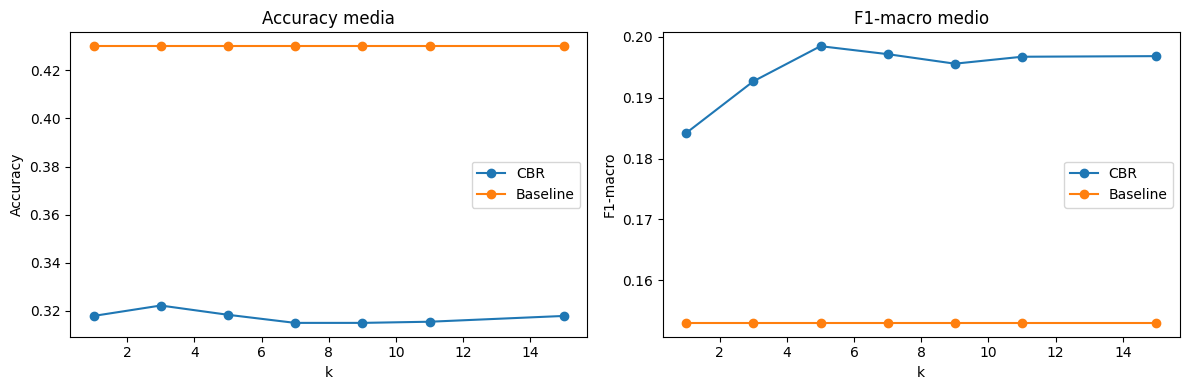

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sensitivity_df['k'], sensitivity_df['mean_accuracy_cbr'], marker='o', label='CBR')
axes[0].plot(sensitivity_df['k'], sensitivity_df['mean_accuracy_baseline'], marker='o', label='Baseline')
axes[0].set_title('Accuracy media')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(sensitivity_df['k'], sensitivity_df['mean_f1_macro_cbr'], marker='o', label='CBR')
axes[1].plot(sensitivity_df['k'], sensitivity_df['mean_f1_macro_baseline'], marker='o', label='Baseline')
axes[1].set_title('F1-macro medio')
axes[1].set_xlabel('k')
axes[1].set_ylabel('F1-macro')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Exportacion opcional de resultados

Esta celda guarda tablas especificas de este notebook. No sustituye a los CSV generados por `cbr_loio_clean.py`, pero deja una version mas legible para memoria o revision.

In [34]:
OUTPUT_DIR = Path('../base_de_casos/cbr_similarity_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

main_metrics_path = OUTPUT_DIR / 'cbr_loio_clean_metrics_by_field_k11_with_baseline_f1.csv'
summary_path = OUTPUT_DIR / 'cbr_loio_clean_summary_k11_with_baseline_f1.csv'
sensitivity_path = OUTPUT_DIR / 'cbr_loio_clean_k_sensitivity_with_baseline_f1.csv'

main_metrics.to_csv(main_metrics_path, index=False)
summary_metrics.to_csv(summary_path, index=False)
sensitivity_df.to_csv(sensitivity_path, index=False)

print(main_metrics_path)
print(summary_path)
print(sensitivity_path)

../base_de_casos/cbr_similarity_outputs/cbr_loio_clean_metrics_by_field_k11_with_baseline_f1.csv
../base_de_casos/cbr_similarity_outputs/cbr_loio_clean_summary_k11_with_baseline_f1.csv
../base_de_casos/cbr_similarity_outputs/cbr_loio_clean_k_sensitivity_with_baseline_f1.csv


## 10. Lectura de resultados

La lectura esperada es:

- El baseline mayoritario obtiene una accuracy media superior, porque predice las categorias mas frecuentes.
- El CBR obtiene un F1-macro medio cercano o ligeramente superior, lo que indica un comportamiento menos concentrado en la clase mayoritaria.
- En campos multivalor, Jaccard es mas informativo que la coincidencia exacta.
- `k=11` se adopta como compromiso entre rendimiento agregado, estabilidad y tamano del vecindario.